In [144]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.family'] = 'Malgun Gothic'

df = pd.read_csv('최종전처리.csv', encoding='cp949')
df

,Unnamed: 0,시도,일시,fire,평균기온(°C),최고기온(°C),일강수량(mm),평균 상대습도(%),최대 풍속(m/s),평균 풍속(m/s),최저기온(°C),일 최심적설(cm),실효습도,년도,논_비율,밭_비율,도시_산림_인접지수
0,0,경북,2016-01-03,1,4.376923,16.3,0.0,72.415385,6.5,1.184615,-6.6,0.0,59.201499,2016,14.049405,19.069746,10.158780
1,1,경북,2016-01-04,0,5.192308,12.9,0.0,50.807692,8.3,2.715385,-6.2,0.0,55.198808,2016,14.049405,19.069746,10.158780
2,2,경북,2016-01-05,0,0.423077,7.0,0.0,33.076923,8.1,2.646154,-7.0,0.0,46.443746,2016,14.049405,19.069746,10.158780
3,3,경북,2016-01-06,1,0.084615,7.0,0.0,46.515385,9.6,2.976923,-9.8,0.0,43.977776,2016,14.049405,19.069746,10.158780
4,4,경북,2016-01-07,0,-0.030769,6.4,0.0,44.192308,8.1,3.092308,-9.2,0.0,41.731961,2016,14.049405,19.069746,10.158780
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62013,63262,제주,2025-12-27,0,4.200000,9.4,0.0,59.325000,6.1,2.625000,-2.8,0.0,54.115659,2025,0.001604,7.444119,6.744372
62014,63263,제주,2025-12-28,0,8.950000,13.7,0.0,53.875000,12.7,2.800000,1.0,0.0,51.877249,2025,0.001604,7.444119,6.744372
62015,63264,제주,2025-12-29,0,12.325000,17.3,0.0,60.600000,11.5,4.400000,5.0,0.0,52.197272,2025,0.001604,7.444119,6.744372
62016,63265,제주,2025-12-30,0,8.325000,15.8,0.0,51.725000,10.3,3.700000,3.6,0.0,49.414664,2025,0.001604,7.444119,6.744372


In [145]:
df = df.drop(['Unnamed: 0'],axis=1)

In [146]:
print(df.isnull().sum())

시도            0
일시            0
fire          0
평균기온(°C)      0
최고기온(°C)      0
일강수량(mm)      0
평균 상대습도(%)    0
최대 풍속(m/s)    0
평균 풍속(m/s)    0
최저기온(°C)      0
일 최심적설(cm)    0
실효습도          0
년도            0
논_비율          0
밭_비율          0
도시_산림_인접지수    0
dtype: int64


In [147]:
# smote한 것
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

sc = StandardScaler()
df = df.drop(['시도','일시','년도','최고기온(°C)', '최저기온(°C)'],axis=1)
X = df.drop('fire',axis=1).to_numpy()
y = df['fire'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42,test_size=0.2,stratify=y)
# X_train_sc = sc.fit_transform(X_train)
# X_test_sc = sc.transform(X_test)

smote = SMOTE(random_state=42)
X_resample, y_resample = smote.fit_resample(X_train,y_train)
print(np.bincount(y_resample))



[45542 45542]


In [148]:
from xgboost import XGBClassifier

xgb_clf = XGBClassifier(
    n_estimators=10,
    max_depth=3,
    learning_rate=0.1,
    random_state=0
)

xgb_clf.fit(X_resample,y_resample)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [149]:
print(xgb_clf.score(X_resample,y_resample))
print(xgb_clf.score(X_test,y_test))

0.8136884633964253
0.8169138987423412


In [157]:
from sklearn.metrics import accuracy_score, classification_report, recall_score, f1_score,precision_score

y_pred_train = xgb_clf.predict(X_train)
y_pred_test = xgb_clf.predict(X_test)

print(f'accuracy : {accuracy_score(y_test, y_pred_test)}')
print(f'recall :{recall_score(y_test, y_pred_test)}')
print(f'precision : {precision_score(y_test, y_pred_test)}')

print(f'f1 : {f1_score(y_test, y_pred_test)}')
print(classification_report(y_test, y_pred_test))

accuracy : 0.8169138987423412
recall :0.8163064833005894
precision : 0.28507718696397943
f1 : 0.4225781845919146
              precision    recall  f1-score   support

           0       0.98      0.82      0.89     11386
           1       0.29      0.82      0.42      1018

    accuracy                           0.82     12404
   macro avg       0.63      0.82      0.66     12404
weighted avg       0.92      0.82      0.85     12404



ROC-AUC: 0.9007057921405566


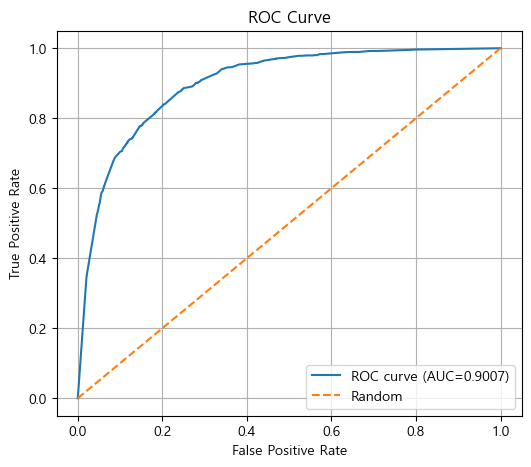

In [151]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# 1) 양성(클래스=1) 확률 예측
y_score_test = xgb_clf.predict_proba(X_test)[:, 1]

# 2) AUC 계산
auc = roc_auc_score(y_test, y_score_test)
print("ROC-AUC:", auc)

# 3) ROC Curve 좌표 계산
fpr, tpr, thresholds = roc_curve(y_test, y_score_test, pos_label=1)

# 4) ROC Curve 그리기
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC={auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

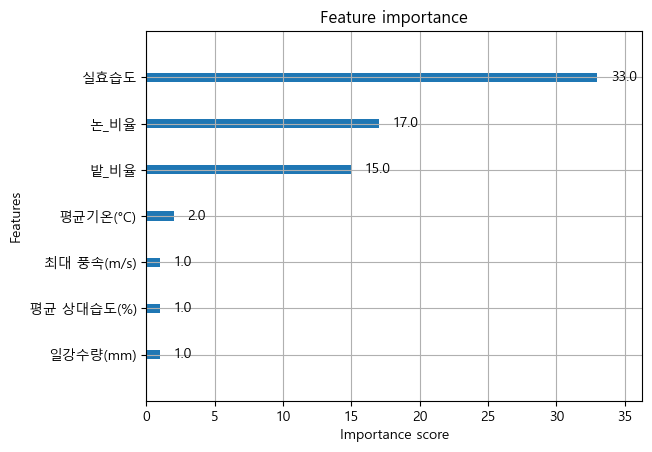

In [152]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

xgb_clf.get_booster().feature_names = df.drop('fire', axis=1).columns.tolist()
plot_importance(xgb_clf, max_num_features=20)
plt.show()


Confusion Matrix:
 [[9302 2084]
 [ 187  831]]


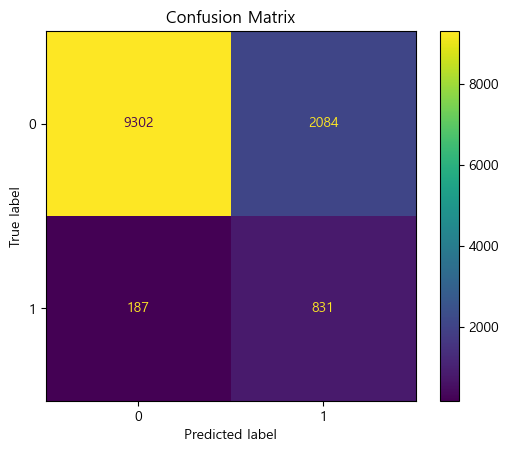

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_test)
print("Confusion Matrix:\n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(values_format='d')
plt.title("Confusion Matrix")
plt.show()


In [ ]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
params = {
    "n_estimators": range(100, 1501, 50),      
    "max_depth": range(2, 13, 1),              
    "learning_rate": [0.005, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.2],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rd_search = RandomizedSearchCV(
    xgb_clf,
    params,
    cv=cv,
    n_iter=80,                 
    scoring="f1",              
    random_state=0,
    n_jobs=-1,
    verbose=1
)
rd_search.fit(X_train, y_train)

print(rd_search.best_params_)
print(rd_search.best_score_)